# Lecture 06

### Model Comparison: AIC and BIC

#### Operational Definitions
Given $N$ data points, $k$ free parameters, and the maximum likelihood $\hat{L}$:

* **Akaike Information Criterion (AIC):**
  $$\text{AIC} = 2k - 2\ln(\hat{L})$$
  *(Small-sample correction, $N/k \lesssim 40$)*: $\text{AICc} = \text{AIC} + \frac{2k(k+1)}{N - k - 1}$

* **Bayesian Information Criterion (BIC):**
  $$\text{BIC} = k\ln(N) - 2\ln(\hat{L})$$

Lower values indicate a preferred model. For $N \ge 8 \implies \ln(N) > 2$, meaning **BIC penalizes extra parameters more harshly than AIC**.

#### Theoretical Foundations

* **AIC (Information Theory):**
  * **Basis:** Asymptotic approximation (to the Kullback-Leibler (K-L) divergence) between the true data-generating distribution and the candidate model.
  * **Objective:** Predictive accuracy—minimizes out-of-sample information loss.
  * **Property:** Efficient but *not consistent* (tends to select slightly over-parameterized models as $N \to \infty$).

* **BIC (Bayesian Inference):**
  * **Basis:** Asymptotic expansion (Laplace approximation) of the **marginal likelihood** (Bayesian evidence $p(D\mid M)$) under non-informative priors.
  * **Objective:** Identification—finds the "true" physical model assuming it lies within the candidate set.
  * **Property:** *Consistent* (the probability of recovering the true model approaches $1$ as $N \to \infty$).

### Boot vs Jack


* **Boot**: works well for every statistics: mean, variance but also ranked based stats. Maps out the entire distribution since can be done N times with no restriction. It's computationally expensive and relies on random noise (thus not reproducable).

* **Jack**: doesn't work on ranked-based statistics. Doesn't map out the distribution of the estimator since it's limited by sample size. It's computationally cheaper and deterministic. It's built for bias correction of the estimator.

# Black-hole binary formation channels with gaussian mixtures.

### Introduction

Some events form in different astrophysical environments than others. You want to figure out how many of formation channels are at play.
The strategy here is to fit a Gaussian Mixture model: that is, my model is a sum of N gaussians each with mean $\mu_j$ and standard deviation $\sigma_j$
 and weight $\alpha_j$:

 $$p(x_i|\theta) = \sum_{i=1}^N \alpha_j \mathcal{N}(\mu_j, \sigma_j)$$

This depends on $3N - 1$ parameters (not $3N$ because the sum of the $\alpha_j$ must be unity to ensure that this is a probability, 1 constrain). The dataset contains the masses of BH binaries.

### Tasks

- Load this file (np.load) and complete a quick exploration of the data. How many modes do you think you see?
- We'll use sklearn.mixture.GaussianMixture. You first need to define the model (instance of a class), and then train it on the data using the fit method (the data provided are already in the right numpy format!). This will output the trained model, which has various attributes.

- Complete the fit 10 times with $N = 1,...,10$ Gaussians.
  
$Note$: sklearn by default will use the so-called Expectation-Maximization algorithm, which is one of the many great things in data science we don't have time to study in this class.

- For each of this fits, compute the AIC (easy! It's an attribute of the trained model!). Plot $N$ vs AIC: which model is preferred?
- Plot the preferred solution on top of the input data. You should get a very nice fit!

In [18]:
import numpy as np
from matplotlib import pyplot as plt

file_path = 'formationchannels.npy'
data = np.load(file_path)
N=3000
set_x = np.linspace(-10,50, N)

print(f"The \"shape\" of the data set is: {data.shape}")

The "shape" of the data set is: (2950, 1)


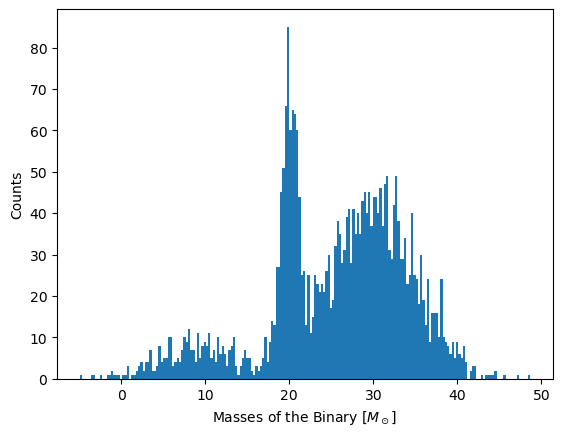

In [19]:
plt.hist(data, bins = 200)
plt.ylabel("Counts")
plt.xlabel(r"Masses of the Binary [$M_\odot$]")
plt.show()

### Gaussian Mixture

In [20]:
from sklearn.mixture import GaussianMixture as gm

def likelihood(x, mu, sigma):
    norm = 1/np.sqrt(2 * np.pi * sigma**2)
    exp = np.exp(-(x - mu)**2/(2*sigma**2))
    p = norm * exp
    return p

Try with 3 gaussians

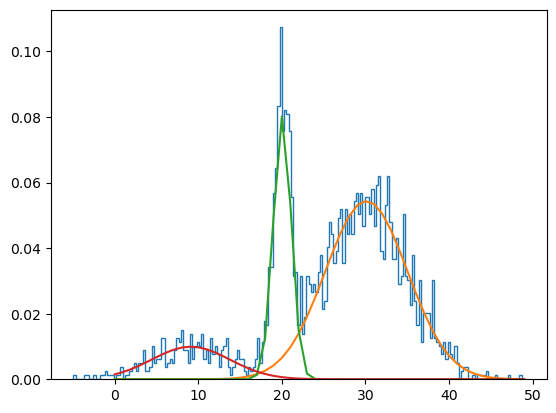

GMM parameters learnt from data
Componente 1:
  Peso (w)    : 0.6697
  Media (mu)  : 30.1201
  Varianza    : 24.1446
  Dev. St. (s): 4.9137

Componente 2:
  Peso (w)    : 0.2141
  Media (mu)  : 20.0510
  Varianza    : 1.1321
  Dev. St. (s): 1.0640

Componente 3:
  Peso (w)    : 0.1163
  Media (mu)  : 9.0943
  Varianza    : 21.8155
  Dev. St. (s): 4.6707



In [30]:
gm1 = gm(n_components=3).fit(data)
set_x = np.arange(0,50)
gaussians = np.array([pesi * likelihood(set_x, medie, np.sqrt(varianze)) 
                      for pesi, medie, varianze in zip(gm1.weights_, gm1.means_.ravel(), gm1.covariances_.ravel())])

plt.hist(data, bins = 200, histtype = 'step', density=True)
plt.plot(set_x, gaussians.T)
plt.show()

pesi = gm1.weights_
medie = gm1.means_.ravel()
varianze = gm1.covariances_.ravel()

print("GMM parameters learnt from data")
for i in range(gm1.n_components):
    print(f"Componente {i+1}:")
    print(f"  Peso (w)    : {pesi[i]:.4f}")
    print(f"  Media (mu)  : {medie[i]:.4f}")
    print(f"  Varianza    : {varianze[i]:.4f}")
    print(f"  Dev. St. (s): {np.sqrt(varianze[i]):.4f}\n")

Try different number of gaussians from 1 to 10

In [29]:
n = range(1, 11)
gms = np.array([gm(int(i)).fit(data) for i in n])
many_gaus = []

print("Parametri dei Gaussian Mixture Models")

for gmi in gms:
    n_comp = gmi.n_components
    print(f"MODELLO CON {n_comp} COMPONENTI")
    
    pesi = gmi.weights_
    medie = gmi.means_.ravel()
    varianze = gmi.covariances_.ravel()
    
    for i in range(n_comp):
        print(f"  Componente {i+1}:")
        print(f"    Peso (w)    : {pesi[i]:.4f}")
        print(f"    Media (mu)  : {medie[i]:.4f}")
        print(f"    Varianza    : {varianze[i]:.4f}")
        print(f"    Dev. St. (s): {np.sqrt(varianze[i]):.4f}\n")
        
    plot = np.array([
        likelihood(set_x, mu_i, np.sqrt(sigma_i)) * w_i 
        for mu_i, sigma_i, w_i in zip(medie, varianze, pesi)
    ])
    many_gaus.append(plot)


Parametri dei Gaussian Mixture Models
MODELLO CON 1 COMPONENTI
  Componente 1:
    Peso (w)    : 1.0000
    Media (mu)  : 25.5201
    Varianza    : 70.8877
    Dev. St. (s): 8.4195

MODELLO CON 2 COMPONENTI
  Componente 1:
    Peso (w)    : 0.5567
    Media (mu)  : 30.0320
    Varianza    : 28.3827
    Dev. St. (s): 5.3275

  Componente 2:
    Peso (w)    : 0.4433
    Media (mu)  : 19.8532
    Varianza    : 66.5914
    Dev. St. (s): 8.1604

MODELLO CON 3 COMPONENTI
  Componente 1:
    Peso (w)    : 0.6698
    Media (mu)  : 30.1184
    Varianza    : 24.1575
    Dev. St. (s): 4.9150

  Componente 2:
    Peso (w)    : 0.2140
    Media (mu)  : 20.0506
    Varianza    : 1.1299
    Dev. St. (s): 1.0630

  Componente 3:
    Peso (w)    : 0.1163
    Media (mu)  : 9.0952
    Varianza    : 21.8235
    Dev. St. (s): 4.6716

MODELLO CON 4 COMPONENTI
  Componente 1:
    Peso (w)    : 0.2346
    Media (mu)  : 20.0957
    Varianza    : 1.3261
    Dev. St. (s): 1.1516

  Componente 2:
    Peso (w)    

Valori nella lista n: range(1, 11)
Modelli salvati in many_gaus: 10


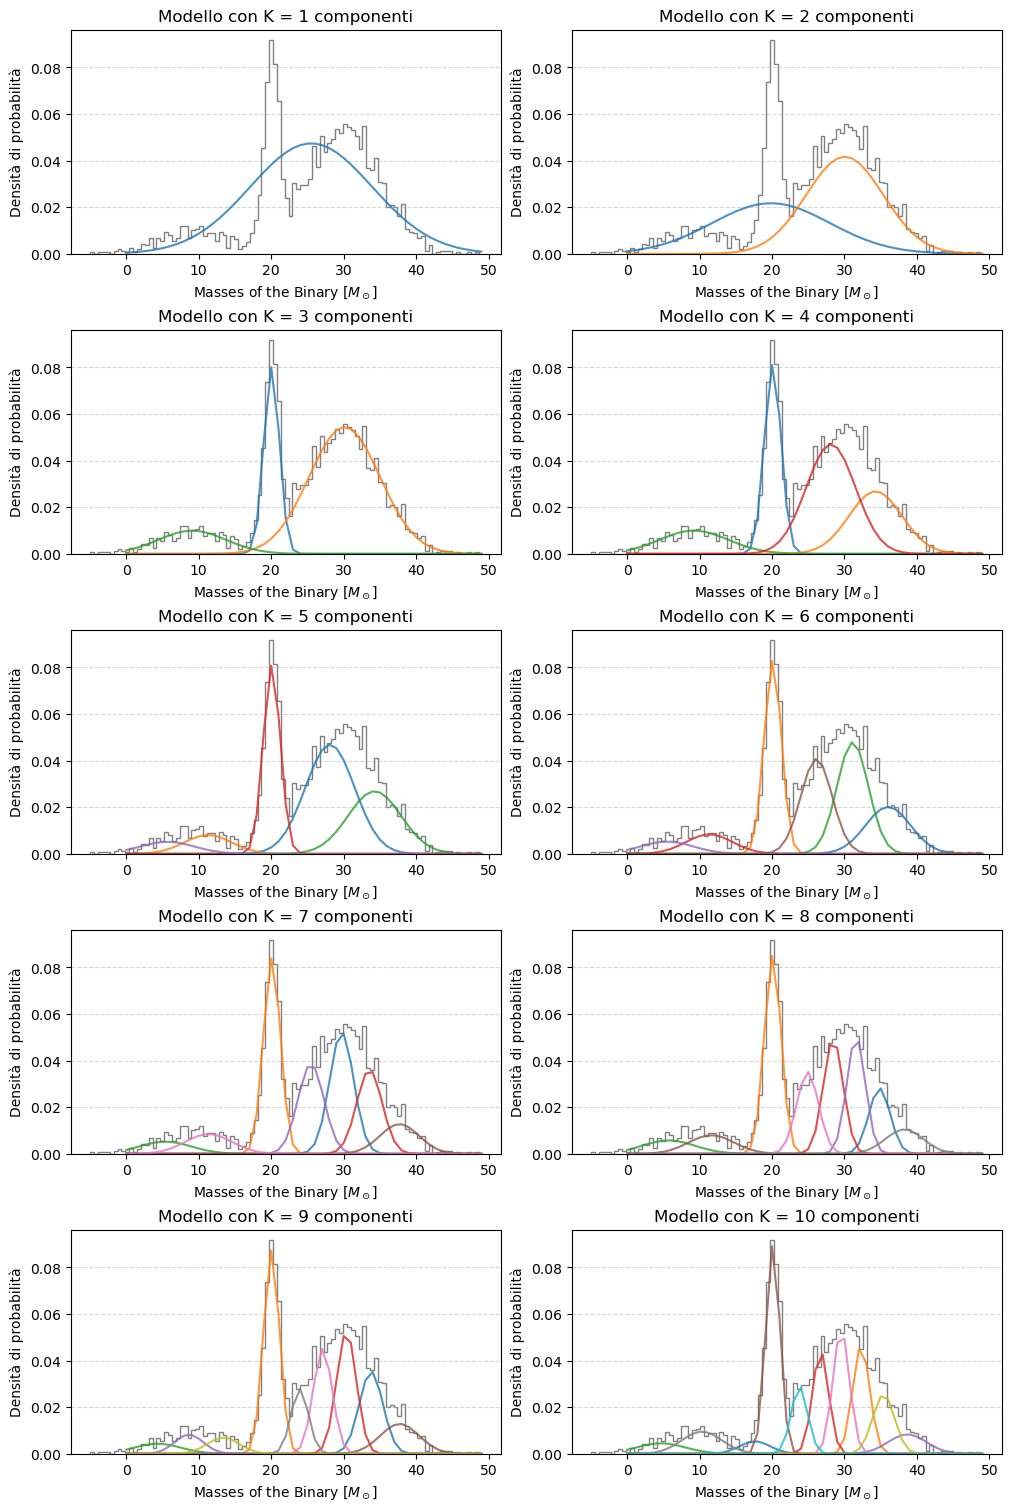

In [25]:
print(f"Valori nella lista n: {n}")
print(f"Modelli salvati in many_gaus: {len(many_gaus)}")
fig, axes = plt.subplots(5, 2, figsize=(10, 15), constrained_layout=True)
axes = axes.flatten() # Trasformiamo la matrice di assi in una lista piatta

for i, ax in enumerate(axes):
    if i >= len(many_gaus):
        ax.set_visible(False)
        continue
        
    gaus_model = many_gaus[i]
    
    #Plot istogramma sui dati (sullo sfondo)
    ax.hist(data, bins=100, histtype='step', density=True, color='gray', label='Dati', zorder=1)
    
    #Plot delle singole gaussiane
    ax.plot(set_x, gaus_model.T, alpha=0.8, zorder=2)
    
    ax.set_title(f"Modello con K = {n[i]} componenti")
    ax.set_xlabel(r"Masses of the Binary [$M_\odot$]")
    ax.set_ylabel("Densità di probabilità")
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### Akaike Information Criterion (AIC)

The **AIC** is an estimator of relative quality of statistical models for a given set of data. It is based on the principle of parsimony: it seeks the best compromise between the goodness-of-fit and the simplicity of the model, introducing a penalty term to avoid **overfitting**.

The mathematical definition is:

$$\text{AIC} = 2k - 2\ln(\hat{L})$$

Where:
* $k$: is the number of estimated parameters in the model (representing the penalty for complexity).
* $\hat{L}$: is the maximum value of the likelihood function for the model.

**Decision Rule:** Given a set of candidate models, the preferred model is the one with the **minimum AIC value**. The $-2\ln(\hat{L})$ term rewards models that fit the data well, while the $2k$ term penalizes unnecessarily complex models.

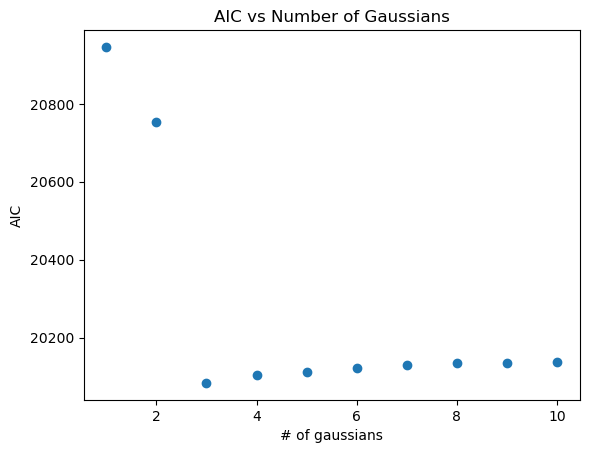

In [24]:
aics = np.array([gmi.aic(data) for gmi in gms])

plt.scatter(n, aics)
plt.title("AIC vs Number of Gaussians")
plt.ylabel("AIC")
plt.xlabel("# of gaussians")
plt.show()